In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from matplotlib.patches import Ellipse
from scipy.fft import fft, fftfreq, fftshift
from scipy.optimize import least_squares

base = Path('.')
X_all_0 = np.load(base / '0528_X_all_0.npy')
X_all_1 = np.load(base / '0528_X_all_1.npy')
y_all_0 = np.load(base / '0528_y_all_0.npy')
y_all_1 = np.load(base / '0528_y_all_1.npy')

In [2]:
#calculate the shots per class

num_0_shots = len(y_all_0)
num_1_shots = len(y_all_1)

print(f'Number of shots for class 0: {num_0_shots}'
      f'\nNumber of shots for class 1: {num_1_shots}')

#calculate samples per shot
samples_per_shot_0 = X_all_0.shape[1]
samples_per_shot_1 = X_all_1.shape[1]

print(f'Number of samples per shot for class 0: {samples_per_shot_0}'
      f'\nNumber of samples per shot for class 1: {samples_per_shot_1}')

Number of shots for class 0: 500000
Number of shots for class 1: 500000
Number of samples per shot for class 0: 1540
Number of samples per shot for class 1: 1540


In [3]:
#IQ samples are interleaved, X looks like [I0, Q0, I1, Q1, I2, Q2, ...]
I_min = min(np.min(X_all_0[:, 0::2]), np.min(X_all_1[:, 0::2]))
I_max = max(np.max(X_all_0[:, 0::2]), np.max(X_all_1[:, 0::2]))
Q_min = min(np.min(X_all_0[:, 1::2]), np.min(X_all_1[:, 1::2]))
Q_max = max(np.max(X_all_0[:, 1::2]), np.max(X_all_1[:, 1::2]))

print(f'Minimum I value: {I_min}, Maximum I value: {I_max}')
print(f'Minimum Q value: {Q_min}, Maximum Q value: {Q_max}')

Minimum I value: -4883.0, Maximum I value: 4822.0
Minimum Q value: -4810.0, Maximum Q value: 4716.0


In [4]:
mean_I_0 = np.mean(X_all_0[:, 0::2])#, axis=0)
mean_Q_0 = np.mean(X_all_0[:, 1::2])#, axis=0)
mean_I_1 = np.mean(X_all_1[:, 0::2])#, axis=0)
mean_Q_1 = np.mean(X_all_1[:, 1::2])#, axis=0)

print(f'Mean I value for state 0: {mean_I_0}, Mean Q value for state 0: {mean_Q_0}')
print(f'Mean I value for state 1: {mean_I_1}, Mean Q value for state 1: {mean_Q_1}')

Mean I value for state 0: 13.279152337662337, Mean Q value for state 0: 137.56756376363637
Mean I value for state 1: 141.674451, Mean Q value for state 1: -62.930896623376626


Covariance matrix for state 0:
[[ 1.10847400e+09 -3.98397462e+08]
 [-3.98397462e+08  1.31627728e+09]]
Covariance matrix for state 1:
[[ 1.50519727e+09 -9.75491229e+08]
 [-9.75491229e+08  2.23312895e+09]]


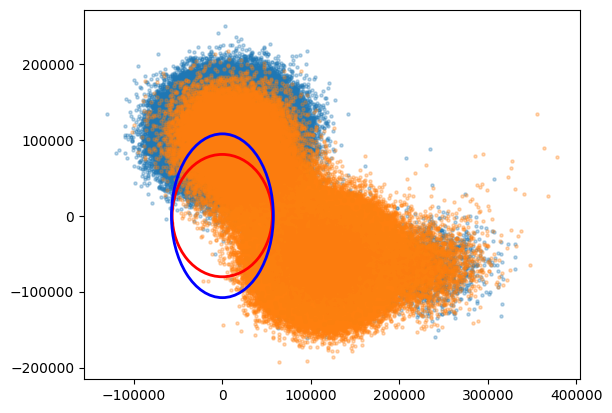

In [5]:
#now calculate the covariance between IQ data
I_0 = np.sum(X_all_0[:,0::2], axis=1)
Q_0 = np.sum(X_all_0[:,1::2], axis=1)
I_1 = np.sum(X_all_1[:,0::2], axis=1)
Q_1 = np.sum(X_all_1[:,1::2], axis=1)

cov_IQ_0 = np.cov(I_0,Q_0)
cov_IQ_1 = np.cov(I_1,Q_1)

print(f'Covariance matrix for state 0:\n{cov_IQ_0}')
print(f'Covariance matrix for state 1:\n{cov_IQ_1}')

#using this matrix calculate eigenvalues and eigenvectors
eigenvalues_0, eigenvectors_0 = np.linalg.eig(cov_IQ_0)
eigenvalues_1, eigenvectors_1 = np.linalg.eig(cov_IQ_1)

plt.scatter(
    I_0,
    Q_0,
    alpha=0.3,
    s=5,
    label="State 0"
)

plt.scatter(
    I_1,
    Q_1,
    alpha=0.3,
    s=5,
    label="State 1"
)

width = 2*np.sqrt(eigenvalues_0[0])*2
height = 2*np.sqrt(eigenvalues_0[1])*2
#plot the ellipse for state 0
ellipse_0 = Ellipse(xy=(mean_I_0, mean_Q_0), width=width, height=height, edgecolor='r', fc='None', lw=2, label='State 0 Covariance Ellipse')
plt.gca().add_patch(ellipse_0)

ellipse_1 = Ellipse(xy=(mean_I_1, mean_Q_1), width=2*np.sqrt(eigenvalues_1[0])*2, height=2*np.sqrt(eigenvalues_1[1])*2, edgecolor='b', fc='None', lw=2, label='State 1 Covariance Ellipse')
plt.gca().add_patch(ellipse_1)


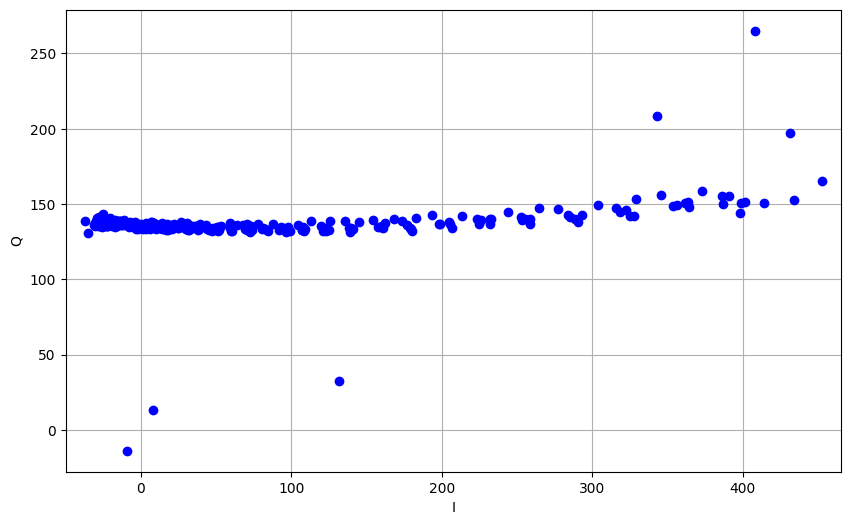

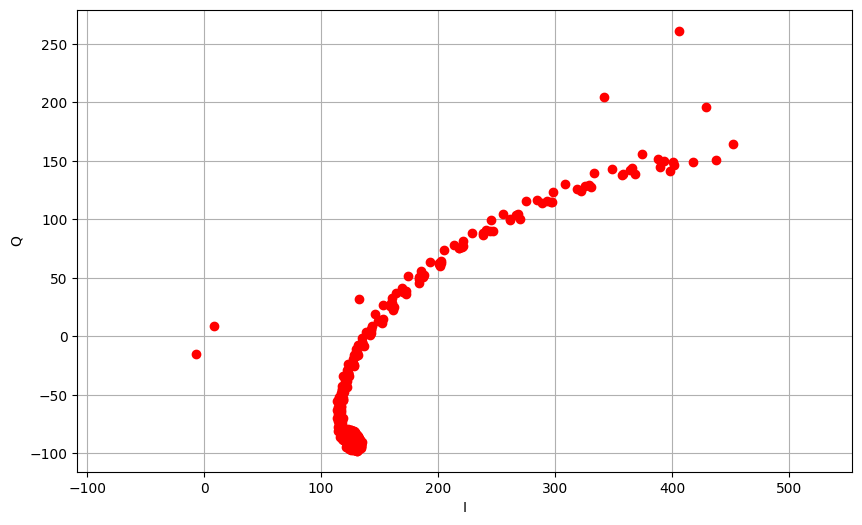

In [6]:
#time domain trajectory
mean_I_0_axis = np.mean(X_all_0[:, 0::2], axis=0)
mean_Q_0_axis = np.mean(X_all_0[:, 1::2], axis=0)
mean_I_1_axis = np.mean(X_all_1[:, 0::2], axis=0)
mean_Q_1_axis = np.mean(X_all_1[:, 1::2], axis=0)


plt.figure(figsize=(10, 6))
plt.plot(mean_I_0_axis, mean_Q_0_axis, 'bo', label='Mean State 0')
plt.xlabel('I')
plt.ylabel('Q')
plt.axis('equal')
plt.grid()

plt.figure(figsize=(10, 6))
plt.plot(mean_I_1_axis, mean_Q_1_axis, 'ro', label='Mean State 1')
plt.xlabel('I')
plt.ylabel('Q')
plt.axis('equal')
plt.grid()

In [7]:
#print the 1 state time domain trajectory
print("Mean State 0 Time Domain Trajectory:")
for i in range(len(mean_I_0_axis)):
    print(f"Sample {i}: I = {mean_I_0_axis[i]}, Q = {mean_Q_0_axis[i]}")
print("Mean State 1 Time Domain Trajectory:")
for i in range(len(mean_I_1_axis)):
    print(f"Sample {i}: I = {mean_I_1_axis[i]}, Q = {mean_Q_1_axis[i]}")

Mean State 0 Time Domain Trajectory:
Sample 0: I = 7.903012, Q = 13.247818
Sample 1: I = -8.913274, Q = -13.903758
Sample 2: I = 132.02983, Q = 32.570742
Sample 3: I = 342.96559, Q = 208.681702
Sample 4: I = 408.276462, Q = 265.127274
Sample 5: I = 431.299654, Q = 196.946842
Sample 6: I = 452.535136, Q = 165.11774
Sample 7: I = 433.998336, Q = 152.635226
Sample 8: I = 414.363866, Q = 150.712062
Sample 9: I = 398.939954, Q = 150.971842
Sample 10: I = 397.966966, Q = 144.273866
Sample 11: I = 401.28621, Q = 151.255636
Sample 12: I = 390.86504, Q = 155.356478
Sample 13: I = 386.612932, Q = 150.228268
Sample 14: I = 385.9702, Q = 155.17732
Sample 15: I = 372.661876, Q = 158.628046
Sample 16: I = 363.318078, Q = 151.01223
Sample 17: I = 364.033572, Q = 147.79209
Sample 18: I = 361.775708, Q = 150.571872
Sample 19: I = 356.258112, Q = 149.49465
Sample 20: I = 353.970116, Q = 148.793298
Sample 21: I = 345.702908, Q = 155.702096
Sample 22: I = 329.413056, Q = 153.451652
Sample 23: I = 324.8127

Noise I for state 0: [[ -609.903012  -671.086726  -135.02983  ...   -51.834294   569.661618
   -399.707136]
 [ -787.903012 -1203.086726 -1632.02983  ...  -460.834294   970.661618
    516.292864]
 [ -782.903012 -1022.086726   328.97017  ... -1254.834294 -1153.338382
     35.292864]
 ...
 [ -734.903012 -1671.086726 -1944.02983  ...   440.165706  -384.338382
    612.292864]
 [ -123.903012   279.913274   110.97017  ... -1138.834294  -283.338382
   -603.707136]
 [  342.096988   984.913274  -125.02983  ... -1082.834294  -511.338382
   -698.707136]]
Noise Q for state 0: [[   54.752182  -546.096242  -383.570742 ... -1287.76409    542.17198
    680.962028]
 [  113.752182   -28.096242   -44.570742 ...   539.23591    261.17198
    165.962028]
 [  151.752182 -1434.096242  -521.570742 ...  -350.76409  -1379.82802
  -1089.037972]
 ...
 [  395.752182   341.903758 -1342.570742 ...  -969.76409     -8.82802
    222.962028]
 [  298.752182   767.903758   214.429258 ...   148.23591   1861.17198
    972.962

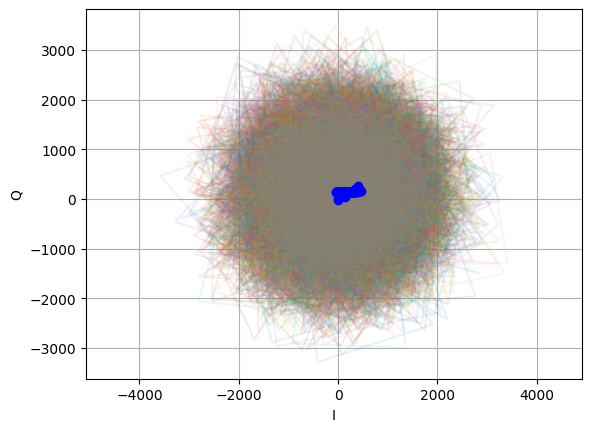

In [8]:
state_I_0 = X_all_0[:, 0::2]
state_Q_0 = X_all_0[:, 1::2]

noise_I_0 = state_I_0 - mean_I_0_axis
noise_Q_0 = state_Q_0 - mean_Q_0_axis

print(f'Noise I for state 0: {noise_I_0}')
print(f'Noise Q for state 0: {noise_Q_0}')

#standard deviation
std_I_0 = np.std(noise_I_0, axis=0)
std_Q_0 = np.std(noise_Q_0, axis=0)

for shot in range(100):
    plt.plot(
        state_I_0[shot],
        state_Q_0[shot],
        alpha=0.1
    )

plt.plot(mean_I_0_axis, mean_Q_0_axis, 'bo', label='Mean State 0')
plt.xlabel("I")
plt.ylabel("Q")
plt.axis("equal")
plt.grid()

In [9]:
# #calculate rotation/phase characteristics

# phase_0 = np.arctan2(mean_Q_0, mean_I_0)
# phase_1 = np.arctan2(mean_Q_1, mean_I_1)

# print(f'Phase for state 0: {phase_0} radians, Phase for state 1: {phase_1} radians')

# sum_phase = np.zeros(770)
# count = 0

# for i in range(len(X_all_0)):

#     I = X_all_0[i, 0::2]
#     Q = X_all_0[i, 1::2]

#     phase = np.unwrap(np.arctan2(Q, I))

#     sum_phase += phase
#     count += 1

# mean_phase_0 = sum_phase / count




# #plot
# plt.figure(figsize=(10, 6))
# plt.hist(phases_0, bins=50, alpha=0.5, label='State 0', color='blue')
# plt.xlabel('Phase (radians)')
# plt.ylabel('Frequency')
# plt.title('Distribution of Phases')
# plt.legend()
# plt.show()

# plt.figure(figsize=(10, 6))
# plt.hist(phases_1, bins=50, alpha=0.5, label='State 1', color='red')
# plt.xlabel('Phase (radians)')
# plt.ylabel('Frequency')
# plt.title('Distribution of Phases')
# plt.legend()
# plt.show()


# #state 0 phase step size
# phase_step_0 = np.diff(phases_0)
# phase_step_1 = np.diff(phases_1)

# print(f'Phase step size for state 0: {phase_step_0}')
# print(f'Phase step size for state 1: {phase_step_1}')

# #plot the phase step size distribution
# plt.figure(figsize=(10, 6))
# plt.hist(phase_step_0, bins=50, alpha=0.5, label='State 0', color='blue')
# plt.xlabel('Phase Step Size (radians)')
# plt.ylabel('Frequency')
# plt.title('Distribution of Phase Step Sizes')
# plt.legend()

# plt.figure(figsize=(10, 6))
# plt.hist(phase_step_1, bins=50, alpha=0.5, label='State 1', color='red')
# plt.xlabel('Phase Step Size (radians)')
# plt.ylabel('Frequency')
# plt.title('Distribution of Phase Step Sizes')
# plt.legend()

# mean_phase_0 = phases_0.mean(axis=0)
# mean_phase_1 = phases_1.mean(axis=0)

# print("mean phase 0:")
# print(mean_phase_0)
# print("mean phase 1:")
# print(mean_phase_1)

In [10]:
mean_I_0_trace = np.mean(X_all_0[:, 0::2], axis=1)
mean_Q_0_trace = np.mean(X_all_0[:, 1::2], axis=1)
mean_I_1_trace = np.mean(X_all_1[:, 0::2], axis=1)
mean_Q_1_trace = np.mean(X_all_1[:, 1::2], axis=1)

noise_I_0_trace = I_0 - mean_I_0_trace
noise_Q_0_trace = Q_0 - mean_Q_0_trace
noise_I_1_trace = I_1 - mean_I_1_trace
noise_Q_1_trace = Q_1 - mean_Q_1_trace                          

sigma_I_0 = np.std(noise_I_0_trace,axis=0)
sigma_Q_0 = np.std(noise_Q_0_trace,axis=0)
sigma_I_1 = np.std(noise_I_1_trace,axis=0)
sigma_Q_1 = np.std(noise_Q_1_trace,axis=0)

print(f'Standard deviation of I for state 0: {sigma_I_0}, Standard deviation of Q for state 0: {sigma_Q_0}')
print(f'Standard deviation of I for state 1: {sigma_I_1}, Standard deviation of Q for state 1: {sigma_Q_1}')

Standard deviation of I for state 0: 33250.481270464734, Standard deviation of Q for state 0: 36233.38202223858
Standard deviation of I for state 1: 38746.44766839395, Standard deviation of Q for state 1: 47194.57519338486


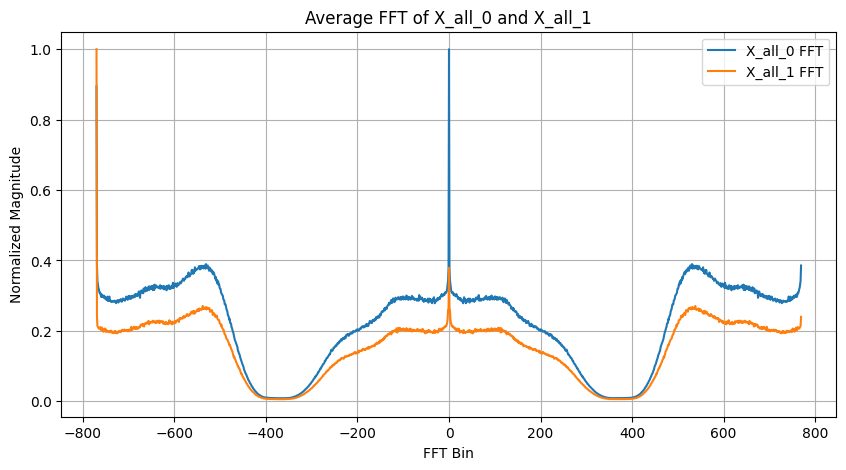

[0.89429746 0.38572195 0.34226672 0.33358965 0.322854   0.31841268
 0.31184499 0.307253   0.3088825  0.302135   0.29676045 0.30364811
 0.29712031 0.29904332 0.30080353 0.29583928 0.29487024 0.29988664
 0.29201431 0.29587362 0.29248283 0.2905791  0.28752249 0.29215514
 0.29738234 0.28489686 0.28922104 0.28685348 0.29748834 0.28502561
 0.28686781 0.28610697 0.28251231 0.28462328 0.2833393  0.28244048
 0.28272744 0.28516199 0.28481908 0.28358649 0.2860642  0.28284483
 0.27993622 0.27876122 0.28175586 0.28642807 0.28449899 0.28676194
 0.28063891 0.28662114 0.28542453 0.28659179 0.28592667 0.29032744
 0.28478088 0.28281787 0.28456963 0.28976221 0.29212197 0.2872337
 0.28803055 0.28898999 0.28564795 0.28875662 0.29289039 0.29744415
 0.2929539  0.29567524 0.28822843 0.29504769 0.29935495 0.2911808
 0.29948515 0.29276324 0.29618908 0.29066583 0.29902192 0.29382814
 0.2956293  0.29942646 0.29469347 0.30056212 0.29652965 0.29559915
 0.29666971 0.3050255  0.29927043 0.29952053 0.29897923 0.304960

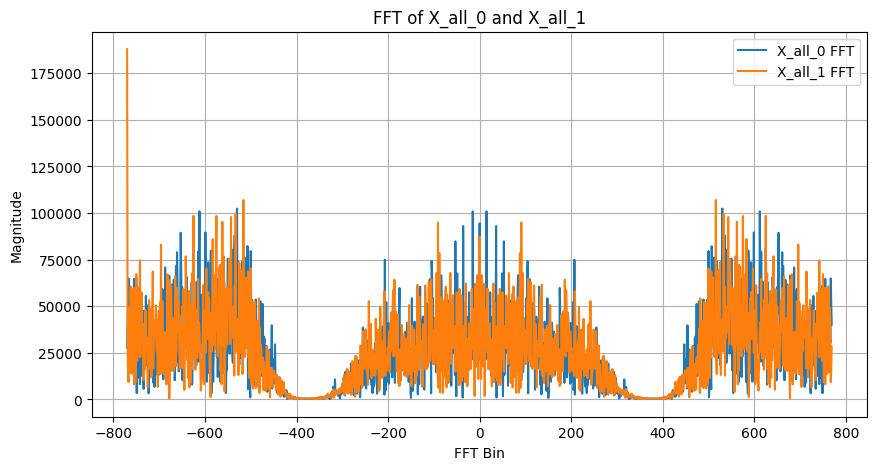

[0.89429746 0.38572195 0.34226672 0.33358965 0.322854   0.31841268
 0.31184499 0.307253   0.3088825  0.302135   0.29676045 0.30364811
 0.29712031 0.29904332 0.30080353 0.29583928 0.29487024 0.29988664
 0.29201431 0.29587362 0.29248283 0.2905791  0.28752249 0.29215514
 0.29738234 0.28489686 0.28922104 0.28685348 0.29748834 0.28502561
 0.28686781 0.28610697 0.28251231 0.28462328 0.2833393  0.28244048
 0.28272744 0.28516199 0.28481908 0.28358649 0.2860642  0.28284483
 0.27993622 0.27876122 0.28175586 0.28642807 0.28449899 0.28676194
 0.28063891 0.28662114 0.28542453 0.28659179 0.28592667 0.29032744
 0.28478088 0.28281787 0.28456963 0.28976221 0.29212197 0.2872337
 0.28803055 0.28898999 0.28564795 0.28875662 0.29289039 0.29744415
 0.2929539  0.29567524 0.28822843 0.29504769 0.29935495 0.2911808
 0.29948515 0.29276324 0.29618908 0.29066583 0.29902192 0.29382814
 0.2956293  0.29942646 0.29469347 0.30056212 0.29652965 0.29559915
 0.29666971 0.3050255  0.29927043 0.29952053 0.29897923 0.304960

In [11]:
#Take FFT of the first 2000 data points 
X_all_0_fft = fftshift(fft(X_all_0[0:2000], axis=1)) 
X_all_1_fft = fftshift(fft(X_all_1[0:2000], axis=1)) 

# Magnitude
X0_mag = np.abs(X_all_0_fft)
X1_mag = np.abs(X_all_1_fft)

# Average over all traces
X0_avg = np.mean(X0_mag, axis=0)
X1_avg = np.mean(X1_mag, axis=0)

# Normalize
X0_avg = X0_avg / np.max(X0_avg)
X1_avg = X1_avg / np.max(X1_avg)

# Frequency axis
N = X_all_0.shape[1]

# Use FFT bin number if you do not know sample rate
freq_axis = np.arange(-N//2, N//2)

# Average plot
plt.figure(figsize=(10, 5))
plt.plot(freq_axis, X0_avg, label="X_all_0 FFT")
plt.plot(freq_axis, X1_avg, label="X_all_1 FFT")

plt.xlabel("FFT Bin")
plt.ylabel("Normalized Magnitude")
plt.title("Average FFT of X_all_0 and X_all_1")
plt.grid(True)
plt.legend()
plt.show()

print(X0_avg[0:1000])
print(X1_avg[0:1000])

# Normal Plot 
plt.figure(figsize=(10, 5))
plt.plot(freq_axis, X0_mag[0], label="X_all_0 FFT")
plt.plot(freq_axis, X1_mag[0], label="X_all_1 FFT")

plt.xlabel("FFT Bin")
plt.ylabel("Magnitude")
plt.title("FFT of X_all_0 and X_all_1")
plt.grid(True)
plt.legend()
plt.show()

print(X0_avg[0:1000])
print(X1_avg[0:1000])

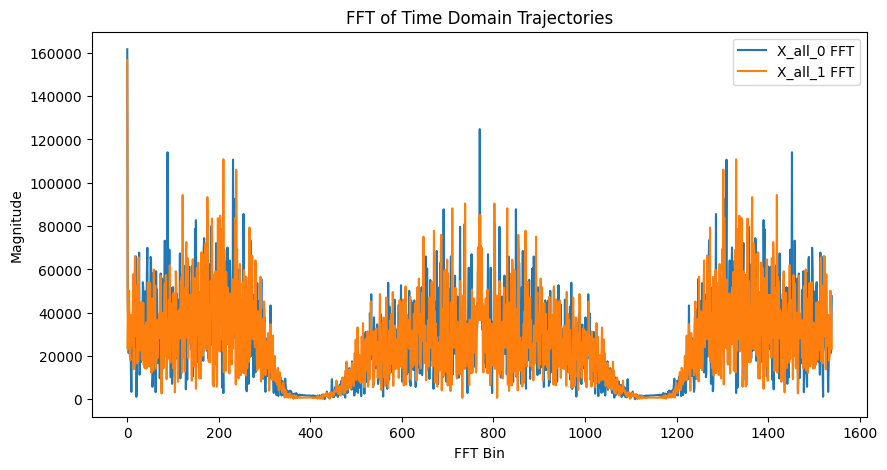

FFT of X_all_0: [[-1.61654000e+05    -0.j         -3.00898003e+04-36953.36288612j
   6.26904740e+03-32386.92053677j ...  2.03471081e+04 -6725.75906222j
   6.26904740e+03+32386.92053677j -3.00898003e+04+36953.36288612j]
 [-3.98760000e+04    -0.j          6.83643059e+03-53313.75847227j
   3.47606269e+04 +1759.72981378j ...  2.98978535e+04-25374.65238138j
   3.47606269e+04 -1759.72981378j  6.83643059e+03+53313.75847227j]
 [-5.89180000e+04    -0.j          2.44730721e+04 -4035.5396221j
   3.28901862e+04 +3875.19441007j ... -4.77060242e+04-50125.70497666j
   3.28901862e+04 -3875.19441007j  2.44730721e+04 +4035.5396221j ]
 ...
 [-1.37824000e+05    -0.j          1.48392473e+03+62229.57649291j
   1.73695156e+04-17922.72316944j ...  2.96731572e+04+50479.47831002j
   1.73695156e+04+17922.72316944j  1.48392473e+03-62229.57649291j]
 [-1.24402000e+05    -0.j          5.76303131e+04-28864.4009577j
   6.86161941e+04 -9080.25644973j ... -1.00066209e+04 -9139.98196733j
   6.86161941e+04 +9080.25644973j

In [ ]:
#Take FFT of the first 2000 data points 
# X_all_0_fft = fftshift(fft(X_all_0, axis=1))#[0:2000], axis=1)) 
# X_all_1_fft = fftshift(fft(X_all_1, axis=1))#[0:2000], axis=1))
X_all_0_fft = fftshift(fft(X_all_0, axis=1[0:2000], axis=1)) 
X_all_1_fft = fftshift(fft(X_all_1, axis=1[0:2000], axis=1))


#plot the FFT of the first 2000 data points for both states
plt.figure(figsize=(10, 5))
plt.plot(np.abs(X_all_0_fft[0]), label="X_all_0 FFT")
plt.plot(np.abs(X_all_1_fft[0]), label="X_all_1 FFT")
plt.xlabel("FFT Bin")
plt.ylabel("Magnitude")
plt.title("FFT of Time Domain Trajectories")
plt.legend()
plt.show()

#print important details of the frequency spectrum
print(f'FFT of X_all_0: {X_all_0_fft}')
print(f'FFT of X_all_1: {X_all_1_fft}')

print(f'FFT Magnitude of X_all_0: {np.abs(X_all_0_fft)}')
print(f'FFT Magnitude of X_all_1: {np.abs(X_all_1_fft)}')

print(f'FFT Phase of X_all_0: {np.angle(X_all_0_fft)}')
print(f'FFT Phase of X_all_1: {np.angle(X_all_1_fft)}')

print(f'FFT Frequency Bins: {freq_axis}')
print(f'FFT Frequency Bins (Shifted): {np.fft.fftshift(freq_axis)}')
print(f'FFT Frequency Bins (Unshifted): {np.fft.fftshift(np.fft.fftfreq(N))}')

In [88]:
# Save FFT arrays for later use
np.save('X_all_0_fft.npy', X_all_0_fft)
np.save('X_all_1_fft.npy', X_all_1_fft)
print('Saved FFT arrays to X_all_0_fft.npy and X_all_1_fft.npy')

Saved FFT arrays to X_all_0_fft.npy and X_all_1_fft.npy


In [89]:
# Load the saved FFT arrays for future use
X_all_0_fft_loaded = np.load('X_all_0_fft.npy')
X_all_1_fft_loaded = np.load('X_all_1_fft.npy')

print('Loaded FFT arrays from disk:')
print(X_all_0_fft_loaded.shape)
print(X_all_1_fft_loaded.shape)

Loaded FFT arrays from disk:
(500000, 1540)
(500000, 1540)


In [13]:
var_I_0 = np.var(I_0)
var_Q_0 = np.var(Q_0)
var_I_1 = np.var(I_1)
var_Q_1 = np.var(Q_1)

cov_IQ_0_scalar = cov_IQ_0[0, 1]
cov_IQ_1_scalar = cov_IQ_1[0, 1]

cov_t_0 = np.array([
    [var_I_0, cov_IQ_0_scalar],
    [cov_IQ_0_scalar, var_Q_0]
])

cov_t_1 = np.array([
    [var_I_1, cov_IQ_1_scalar],
    [cov_IQ_1_scalar, var_Q_1]
])

In [14]:
I_trace = np.mean(X_all_0[:, 0::2], axis=1)
Q_trace = np.mean(X_all_0[:, 1::2], axis=1)

I_s = np.sum(I_trace)
Q_s = np.sum(Q_trace)

phi_s = np.arctan2(Q_s, I_s)
phi = np.random.uniform(0, 2*np.pi)
phi_sigma_0 = phi_s
phi_sigma_1 = phi_s
phi_0 = phi
phi_1 = phi

In [27]:
def calculate_mean_phase(X):

    sum_phase = np.zeros(770)

    for i in range(len(X)):

        I = X[i,0::2]
        Q = X[i,1::2]

        phase = np.unwrap(np.arctan2(Q,I))

        sum_phase += phase

    return sum_phase / len(X)


mean_phase_0 = calculate_mean_phase(X_all_0)
mean_phase_1 = calculate_mean_phase(X_all_1)

In [28]:
#fit delta_0 and delta_1 from their respective trajectories
delta_0 = mean_phase_0[-1] - mean_phase_0[0]
delta_1 = mean_phase_1[-1] - mean_phase_1[0]

In [29]:
mean_real0 = np.mean(X_all_0, axis=0)
mean_real1 = np.mean(X_all_1, axis=0)

z0_real = mean_real0[0::2] + 1j*mean_real0[1::2]
z1_real = mean_real1[0::2] + 1j*mean_real1[1::2]

print(z0_real.shape)
print(z1_real.shape)

(770,)
(770,)


In [78]:
def cavity_response(params,state,n=770,dt=2e-9):

    kappa, delta0, delta1, drive_amp, a_phase, gain = params

    delta = delta0 if state==0 else delta1

    a=np.zeros(n,dtype=complex)
    #a[0] = (np.sqrt(kappa) * drive_amp) / (1j * delta + (kappa / 2))
    a[0] = a[0].real + 1j*a[0].imag


    for i in range(n-1):

        da = (
            -(1j*delta+kappa/2)*a[i]
            + np.sqrt(kappa)*drive_amp
        )

        a[i+1]=a[i]+da*dt

    z = gain*a*np.exp(1j*a_phase)
    

    return z

In [79]:
def readout_chain(a, state):

    # gain (from your ADC scale)
    gain = 4000 * np.random.normal(1, 0.05)
    #gain = 3000

    # global phase rotation (LO / mixer / FPGA)
    phi_mu, phi_sigma = (phi_0, phi_sigma_0) if state == 0 else (phi_1, phi_sigma_1)
    phi = np.random.normal(phi_mu, phi_sigma)

    z = gain * a * np.exp(1j * phi)

    return z

In [111]:
def residual(params, state, target):
    n = len(target)
    z = cavity_response(params, state, n=n)
    #weights = np.exp(-np.arange(n) / 200)
    weights = np.exp(-np.arange(n) / 275)

    residual = weights * (z - target)
    return np.concatenate([residual.real, residual.imag])

# def residual(params,state,target):

#     z=cavity_response(params,state)

#     return np.concatenate(
#         [
#             z.real-target.real,
#             z.imag-target.imag
#         ]
#     )


In [112]:
initial = [
    1/(100e-9),       # kappa
    -2*np.pi*2e6,     # delta0
     2*np.pi*2e6,     # delta1
    1,                # drive
    0,                # phase
    3000              # gain
]

fit0 = least_squares(
    lambda p: residual(p,0,z0_real),
    initial
)

fit1 = least_squares(
    lambda p: residual(p,1,z1_real),
    initial
)

params0 = fit0.x
params1 = fit1.x

print(fit0.x)
print(fit1.x)

[ 4.40165914e+07 -5.29249703e+07  1.25663706e+07  2.12327941e+03
  3.74799642e+01  7.57496428e+02]
[ 1.05310789e+07 -1.25663706e+07  3.29512990e+07  1.71265986e+02
  1.70793662e+02  1.78815426e+03]


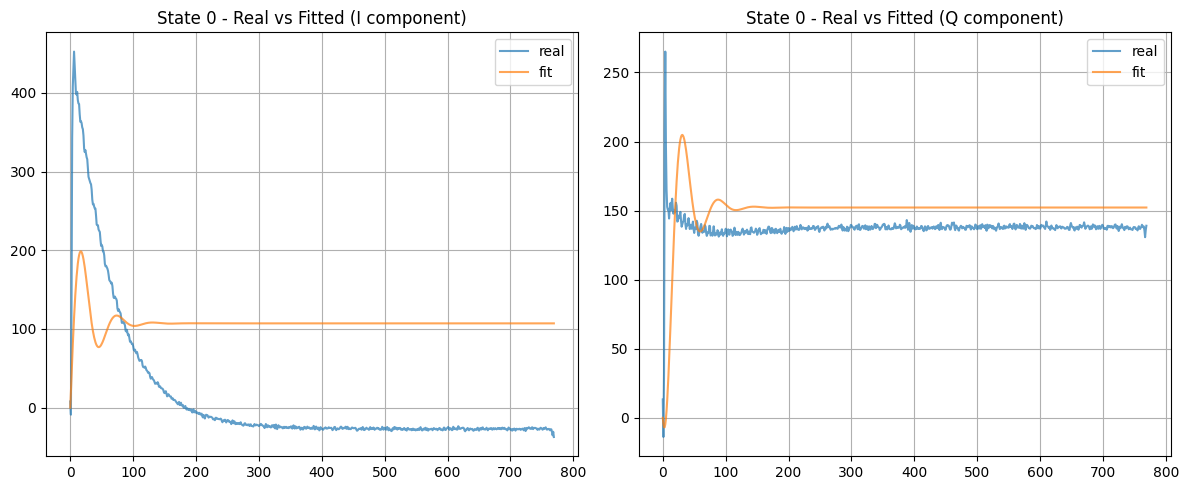

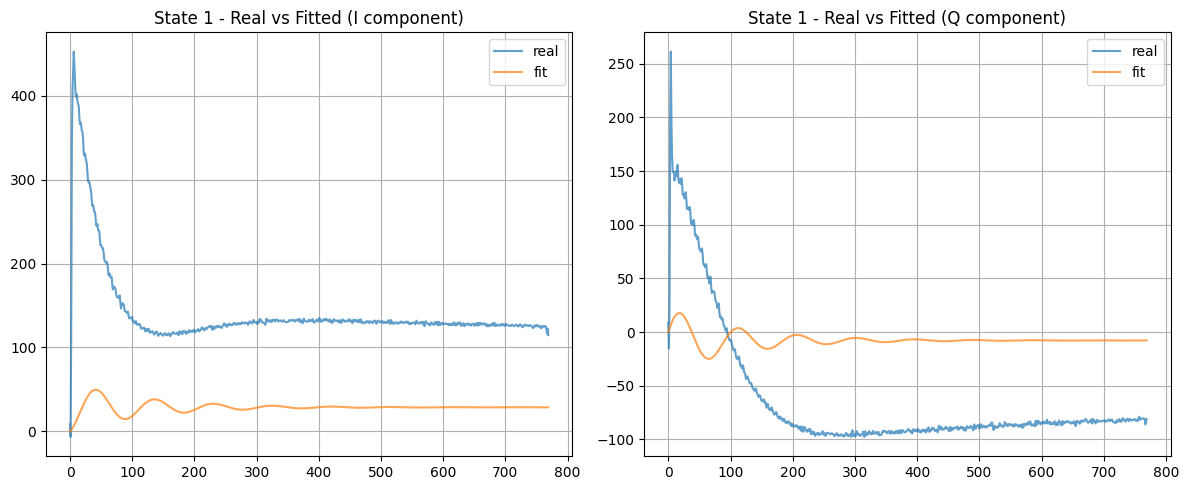

State 0 fit max magnitude: 252.93369159343288
State 0 fit I std: 14.126319356931972
State 0 fit Q std: 19.92495710576569
State 1 fit max magnitude: 50.1046263051488
State 1 fit I std: 5.7654283520166745
State 1 fit Q std: 5.982134080292107


In [113]:
# Validate fitted cavity response parameters
z0_fit = cavity_response(params0, 0)
z1_fit = cavity_response(params1, 1)

# Compare real vs fitted for state 0
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(z0_real.real, label="real", alpha=0.7)
plt.plot(z0_fit.real, label="fit", alpha=0.7)
plt.legend()
plt.title("State 0 - Real vs Fitted (I component)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(z0_real.imag, label="real", alpha=0.7)
plt.plot(z0_fit.imag, label="fit", alpha=0.7)
plt.legend()
plt.title("State 0 - Real vs Fitted (Q component)")
plt.grid()
plt.tight_layout()
plt.show()

# Compare real vs fitted for state 1
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(z1_real.real, label="real", alpha=0.7)
plt.plot(cavity_response(params1, 1).real, label="fit", alpha=0.7)
plt.legend()
plt.title("State 1 - Real vs Fitted (I component)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(z1_real.imag, label="real", alpha=0.7)
plt.plot(cavity_response(params1, 1).imag, label="fit", alpha=0.7)
plt.legend()
plt.title("State 1 - Real vs Fitted (Q component)")
plt.grid()
plt.tight_layout()
plt.show()

# Print fit quality metrics
print(f"State 0 fit max magnitude: {np.max(np.abs(z0_fit))}")
print(f"State 0 fit I std: {np.std(z0_fit.real)}")
print(f"State 0 fit Q std: {np.std(z0_fit.imag)}")

print(f"State 1 fit max magnitude: {np.max(np.abs(cavity_response(params1, 1)))}")
print(f"State 1 fit I std: {np.std(cavity_response(params1, 1).real)}")
print(f"State 1 fit Q std: {np.std(cavity_response(params1, 1).imag)}")

In [83]:
def generate_shot(state):

    if state==0:
        cov=cov_t_0
        phi_mu=phi_0
        phi_sigma=phi_sigma_0
        params=params0

    else:
        cov=cov_t_1
        phi_mu=phi_1
        phi_sigma=phi_sigma_1
        params=params1


    # fitted cavity response
    z = cavity_response(params,state)


    # random phase drift
    phi=np.random.normal(phi_mu,phi_sigma)

    z *= np.exp(1j*phi)


    # add electronics noise
    noise=np.random.multivariate_normal(
        [0,0],
        cov,
        size=len(z)
    )

    z += noise[:,0]+1j*noise[:,1]
    

    # interleave
    iq=np.empty(2*len(z))

    iq[0::2]=z.real
    iq[1::2]=z.imag



    return iq

In [84]:
X_2=[]
y_2=[]

for i in range(10000):
    state=np.random.randint(0,2)
    X_2.append(
        generate_shot(state)
        )
    y_2.append(state)


X_2=np.array(X_2)
y_2=np.array(y_2)

#np.save("X_2.npy",X_2)
#np.save("y_2.npy",y_2)

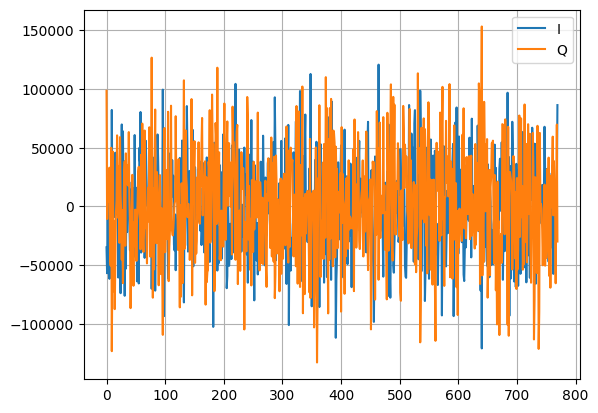

In [85]:
# Plot first shot
shot = X_2[0]
I = shot[0::2]
Q = shot[1::2]

plt.plot(I, label="I")
plt.plot(Q, label="Q")
plt.legend()
plt.grid()
plt.show()

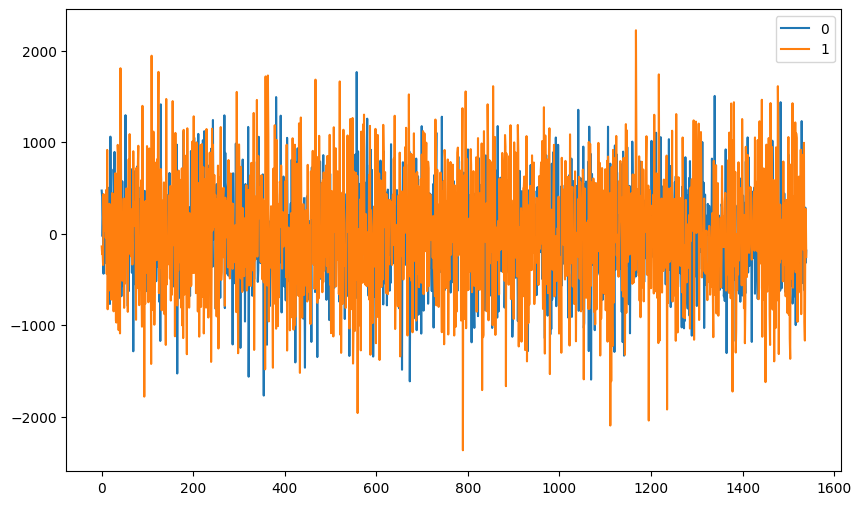

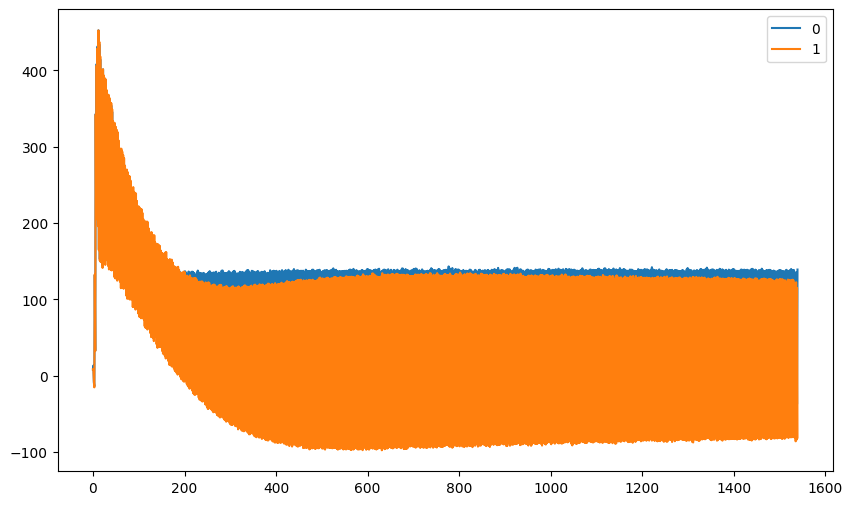

In [86]:
X0 = X_2[y_2==0]
X1 = X_2[y_2==1]

mean0 = np.mean(X0,axis=0)
mean1 = np.mean(X1,axis=0)

plt.figure(figsize=(10, 6))
plt.plot(mean0)
plt.plot(mean1)
plt.legend(["0","1"])

mean_real0 = np.mean(X_all_0, axis=0)
mean_real1 = np.mean(X_all_1, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(mean_real0)
plt.plot(mean_real1)
plt.legend(["0","1"])